In [2]:
import pandas as pd 
import sqlite3

In [3]:
# Connect to the ChEMBL database
conn = sqlite3.connect("../data/raw/chembl_36.db")
cursor = conn.cursor()

In [12]:
# List of tables in the ChEMBL database
tables = pd.read_sql("""
                    Select name 
                    From sqlite_master
                    WHERE type ="table";""", conn)
tables

,name
0,action_type
1,assay_type
2,chembl_id_lookup
3,confidence_score_lookup
4,curation_lookup
...,...
69,pesticide_classification
70,predicted_binding_domains
71,warning_refs
72,pesticide_class_mapping


In [14]:
for i in tables["name"]:
    print(i)

action_type
assay_type
chembl_id_lookup
confidence_score_lookup
curation_lookup
chembl_release
source
relationship_type
target_type
variant_sequences
bioassay_ontology
data_validity_lookup
activity_smid
activity_stds_lookup
assay_classification
atc_classification
bio_component_sequences
component_sequences
protein_classification
domains
go_classification
structural_alert_sets
products
organism_class
patent_use_codes
usan_stems
version
cell_dictionary
docs
target_dictionary
tissue_dictionary
molecule_dictionary
activity_supp
component_class
component_domains
component_go
component_synonyms
structural_alerts
defined_daily_dose
product_patents
protein_class_synonyms
assays
compound_records
binding_sites
biotherapeutics
compound_properties
compound_structural_alerts
compound_structures
molecule_atc_classification
molecule_hierarchy
molecule_synonyms
target_components
target_relations
activities
assay_class_map
assay_parameters
biotherapeutic_components
drug_indication
drug_mechanism
drug_w

In [5]:
pd.read_sql("SELECT COUNT(*) FROM activities", conn)


,COUNT(*)
0,24267312


In [6]:
pd.read_sql("SELECT COUNT(*) FROM molecule_dictionary", conn)

,COUNT(*)
0,2878135


In [7]:
pd.read_sql("PRAGMA table_info(activities)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,activity_id,BIGINT,1,None,1
1,1,assay_id,BIGINT,1,None,0
2,2,doc_id,BIGINT,0,None,0
3,3,record_id,BIGINT,1,None,0
4,4,molregno,BIGINT,0,None,0
5,5,standard_relation,VARCHAR(50),0,None,0
6,6,standard_value,NUMERIC,0,None,0
7,7,standard_units,VARCHAR(100),0,None,0
8,8,standard_flag,SMALLINT,0,None,0
9,9,standard_type,VARCHAR(250),0,None,0


In [8]:
df = pd.read_sql_query(
    "SELECT * FROM activities LIMIT 5;",
    conn
2)

print(df)

   activity_id  assay_id  doc_id  record_id  molregno standard_relation  \
0        31863     54505    6424     206172    180094                 >   
1        31864     83907    6432     208970    182268                 =   
2        31865     88152    6432     208970    182268                 >   
3        31866     83907    6432     208987    182855                 =   
4        31867     88153    6432     208987    182855              None   

   standard_value standard_units  standard_flag standard_type  ...  \
0        100000.0             nM              1          IC50  ...   
1          2500.0             nM              1          IC50  ...   
2         50000.0             nM              1          IC50  ...   
3          9000.0             nM              1          IC50  ...   
4             NaN             nM              0          IC50  ...   

  upper_value standard_upper_value  src_id  type relation  value units  \
0        None                 None       1  IC50      

## Main tables

### molecule_dictionary 
most important:

|Feature | Description|
| --- | --- |   
molregno |    	id |   
chembl_id |	public id (CHEMBL1234) |  
pref_name |	name of the compound  |
molecule_type |	small molecule / protein |  

In [20]:
pd.read_sql_query("""SELECT *
FROM molecule_dictionary
LIMIT 10;""", conn)

,molregno,pref_name,chembl_id,max_phase,therapeutic_flag,dosed_ingredient,structure_type,molecule_type,first_approval,oral,...,usan_year,availability_type,usan_stem,polymer_flag,usan_substem,usan_stem_definition,withdrawn_flag,chemical_probe,orphan,veterinary
0,1,None,CHEMBL6329,None,0,0,MOL,Small molecule,None,0,...,None,-1,None,0,None,None,0,0,-1,-1
1,2,None,CHEMBL6328,None,0,0,MOL,Small molecule,None,0,...,None,-1,None,0,None,None,0,0,-1,-1
2,3,None,CHEMBL265667,None,0,0,MOL,Small molecule,None,0,...,None,-1,None,0,None,None,0,0,-1,-1
3,4,None,CHEMBL6362,None,0,0,MOL,Small molecule,None,0,...,None,-1,None,0,None,None,0,0,-1,-1
4,5,None,CHEMBL267864,None,0,0,MOL,Small molecule,None,0,...,None,-1,None,0,None,None,0,0,-1,-1
5,6,None,CHEMBL6363,None,0,0,MOL,Small molecule,None,0,...,None,-1,None,0,None,None,0,0,-1,-1
6,7,None,CHEMBL6352,None,0,0,MOL,Small molecule,None,0,...,None,-1,None,0,None,None,0,0,-1,-1
7,8,None,CHEMBL268097,None,0,0,MOL,Small molecule,None,0,...,None,-1,None,0,None,None,0,0,-1,-1
8,9,None,CHEMBL266457,None,0,0,MOL,Small molecule,None,0,...,None,-1,None,0,None,None,0,0,-1,-1
9,10,None,CHEMBL268556,None,0,0,MOL,Small molecule,None,0,...,None,-1,None,0,None,None,0,0,-1,-1


### compound_structures 
most important:

|Feature | Description|
| --- | --- |   
molregno |    	id |   
canonical_smiles |	chemical representation|
standard_inchi |	chemical identifier|

In [23]:
pd.read_sql_query("""SELECT *
FROM compound_structures
LIMIT 10;""", conn)

,molregno,molfile,standard_inchi,standard_inchi_key,canonical_smiles
0,1,\n RDKit 2D\n\n 24 26 0 0 0 0...,InChI=1S/C17H12ClN3O3/c1-10-8-11(21-17(24)20-1...,OWRSAHYFSSNENM-UHFFFAOYSA-N,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl
1,2,\n RDKit 2D\n\n 25 27 0 0 0 0...,InChI=1S/C18H12N4O3/c1-11-8-14(22-18(25)21-16(...,ZJYUMURGSZQFMH-UHFFFAOYSA-N,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1
2,3,\n RDKit 2D\n\n 25 27 0 0 0 0...,InChI=1S/C18H16ClN3O3/c1-10-7-14(22-18(25)21-1...,YOMWDCALSDWFSV-UHFFFAOYSA-N,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1
3,4,\n RDKit 2D\n\n 23 25 0 0 0 0...,InChI=1S/C17H13N3O3/c1-11-2-4-12(5-3-11)16(22)...,PSOPUAQFGCRDIP-UHFFFAOYSA-N,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1
4,5,\n RDKit 2D\n\n 24 26 0 0 0 0...,InChI=1S/C17H12ClN3O3/c1-10-8-13(21-17(24)20-1...,KEZNSCMBVRNOHO-UHFFFAOYSA-N,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1
5,6,\n RDKit 2D\n\n 23 25 0 0 0 0...,InChI=1S/C17H13N3O3/c1-11-9-13(20-17(23)19-15(...,ZKEKOOJDMYTEMP-UHFFFAOYSA-N,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1
6,7,\n RDKit 2D\n\n 25 27 0 0 0 0...,InChI=1S/C17H11BrClN3O3/c1-9-6-10(18)2-4-12(9)...,OKZQSFTUAACQQS-UHFFFAOYSA-N,Cc1cc(Br)ccc1C(=O)c1ccc(-n2ncc(=O)[nH]c2=O)cc1Cl
7,8,\n RDKit 2D\n\n 25 27 0 0 0 0...,InChI=1S/C16H8Cl3N3O3/c17-8-1-3-10(12(18)5-8)1...,STDSVETYHZLIBJ-UHFFFAOYSA-N,O=C(c1ccc(Cl)cc1Cl)c1ccc(-n2ncc(=O)[nH]c2=O)cc1Cl
8,9,\n RDKit 2D\n\n 27 29 0 0 0 0...,"InChI=1S/C17H12ClN3O5S/c1-27(25,26)12-5-2-10(3...",NKQAZJTVQHGKAX-UHFFFAOYSA-N,CS(=O)(=O)c1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)...
9,10,\n RDKit 2D\n\n 46 52 0 0 0 0...,InChI=1S/C42H44N4/c1-2-4-6-12-26-44-40-24-28-4...,QFSGJJCWIIUQCT-UUHCYPSGSA-P,c1cc2cc(c1)-c1cccc(c1)C[n+]1ccc(c3ccccc31)NCCC...


## target_dictionary
most important:

| Feature   | description   |
| --------- | ------------- |
| tid | id  |
| chembl_id | target id |
| pref_name | name        |
| organism  | oranism     |

In [25]:
pd.read_sql_query("""SELECT *
FROM target_dictionary
LIMIT 10;""", conn)

,tid,target_type,pref_name,tax_id,organism,chembl_id,species_group_flag
0,1,SINGLE PROTEIN,Maltase-glucoamylase,9606,Homo sapiens,CHEMBL2074,0
1,2,SINGLE PROTEIN,ATP-binding cassette sub-family C member 9,9606,Homo sapiens,CHEMBL1971,0
2,3,SINGLE PROTEIN,"cGMP-specific 3',5'-cyclic phosphodiesterase",9606,Homo sapiens,CHEMBL1827,0
3,4,SINGLE PROTEIN,Voltage-dependent T-type calcium channel subun...,9606,Homo sapiens,CHEMBL1859,0
4,5,SINGLE PROTEIN,Nicotinic acetylcholine receptor alpha subunit,6253,Ascaris suum,CHEMBL1884,0
5,6,SINGLE PROTEIN,Dihydrofolate reductase,9606,Homo sapiens,CHEMBL202,0
6,7,SINGLE PROTEIN,Dihydrofolate reductase,562,Escherichia coli,CHEMBL1809,0
7,8,SINGLE PROTEIN,Tyrosine-protein kinase ABL1,9606,Homo sapiens,CHEMBL1862,0
8,9,SINGLE PROTEIN,Epidermal growth factor receptor,9606,Homo sapiens,CHEMBL203,0
9,10,SINGLE PROTEIN,DNA-directed RNA polymerase subunit beta,83333,Escherichia coli K-12,CHEMBL1852,0


## assays
most important:

| Feature     | description         |
| ----------- | ------------------- |
| assay_id    | id                  |
| target_id   | protein            |
| assay_type  | type of experiment |
| description | description of the experiment         |


In [27]:
pd.read_sql_query("""SELECT *
FROM assays
LIMIT 10;""", conn)

,assay_id,doc_id,description,assay_type,assay_test_type,assay_category,assay_organism,assay_tax_id,assay_strain,assay_tissue,...,curated_by,src_id,src_assay_id,chembl_id,cell_id,bao_format,tissue_id,variant_id,aidx,assay_group
0,1,11087,The compound was tested for the in vitro inhib...,B,None,None,None,NaN,None,None,...,Autocuration,1,None,CHEMBL615117,NaN,BAO_0000019,NaN,None,CLD0,None
1,2,684,Compound was evaluated for its ability to mobi...,F,None,None,None,NaN,None,None,...,Autocuration,1,None,CHEMBL615118,NaN,BAO_0000219,NaN,None,CLD0,None
2,3,15453,None,B,None,None,None,NaN,None,None,...,Autocuration,1,None,CHEMBL615119,NaN,BAO_0000019,NaN,None,CLD0,None
3,4,17841,Binding affinity against A2 adenosine receptor...,B,None,None,Bos taurus,9913.0,None,Striatum,...,Autocuration,1,None,CHEMBL615120,NaN,BAO_0000249,2435.0,None,CLD0,None
4,5,17430,In vitro cell cytotoxicity against 143-B cell ...,F,None,None,Homo sapiens,9606.0,None,None,...,Intermediate,1,None,CHEMBL615121,163.0,BAO_0000219,NaN,None,CLD0,None
5,6,17430,In vitro cell cytotoxicity against 143-B cell ...,F,None,None,Homo sapiens,9606.0,None,None,...,Intermediate,1,None,CHEMBL615122,163.0,BAO_0000219,NaN,None,CLD0,None
6,7,13799,Cytotoxic Activity was evaluated against 143B ...,F,None,None,Mus musculus,10090.0,None,None,...,Intermediate,1,None,CHEMBL615123,163.0,BAO_0000219,NaN,None,CLD0,None
7,8,17774,In vitro cell cytotoxicity was determined agai...,F,None,None,Homo sapiens,9606.0,None,None,...,Expert,1,None,CHEMBL615124,163.0,BAO_0000219,NaN,None,CLD0,None
8,9,3801,Inhibitory activity against tumor osteosarcoma...,F,None,None,Homo sapiens,9606.0,None,None,...,Intermediate,1,None,CHEMBL615125,163.0,BAO_0000219,NaN,None,CLD0,None
9,10,17430,In vitro cell cytotoxicity against 143B-LTK ce...,F,None,None,Homo sapiens,9606.0,None,None,...,Intermediate,1,None,CHEMBL615126,163.0,BAO_0000219,NaN,None,CLD0,None


## activities
### experimental results 
most important:

| Feature        | description      |
| -------------- | ---------------- |
| molregno       | molecule id         |
| assay_id       | experiment id      |
| standard_type  | IC50 / Ki / EC50 |
| standard_value | standar type value            |
| standard_units | units for standar type               |


In [29]:
pd.read_sql_query("""SELECT *
FROM activities
LIMIT 10;""", conn)

,activity_id,assay_id,doc_id,record_id,molregno,standard_relation,standard_value,standard_units,standard_flag,standard_type,...,upper_value,standard_upper_value,src_id,type,relation,value,units,text_value,standard_text_value,action_type
0,31863,54505,6424,206172,180094,>,100000.0,nM,1,IC50,...,None,None,1,IC50,>,100.0,uM,None,None,None
1,31864,83907,6432,208970,182268,=,2500.0,nM,1,IC50,...,None,None,1,IC50,=,2.5,uM,None,None,None
2,31865,88152,6432,208970,182268,>,50000.0,nM,1,IC50,...,None,None,1,IC50,>,50.0,uM,None,None,None
3,31866,83907,6432,208987,182855,=,9000.0,nM,1,IC50,...,None,None,1,IC50,=,9.0,uM,None,None,None
4,31867,88153,6432,208987,182855,None,NaN,nM,0,IC50,...,None,None,1,IC50,None,NaN,uM,None,None,None
5,31868,154606,6570,297547,252199,=,4000.0,nM,1,IC50,...,None,None,1,IC50,=,4.0,uM,None,None,None
6,31869,5080,6570,297547,252199,=,25.0,%,0,% remaining,...,None,None,1,% remaining,=,25.0,%,None,None,None
7,31870,154606,6570,297563,253534,=,17000.0,nM,1,IC50,...,None,None,1,IC50,=,17.0,uM,None,None,None
8,31871,5080,6570,297563,253534,=,27.0,%,0,% remaining,...,None,None,1,% remaining,=,27.0,%,None,None,None
9,31872,154606,6570,297580,253199,=,180.0,nM,1,IC50,...,None,None,1,IC50,=,180.0,nM,None,None,None


In [35]:
pd.read_sql("PRAGMA table_info(assays);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,assay_id,BIGINT,1,None,1
1,1,doc_id,BIGINT,1,None,0
2,2,description,VARCHAR(4000),0,None,0
3,3,assay_type,VARCHAR(1),0,None,0
4,4,assay_test_type,VARCHAR(20),0,None,0
5,5,assay_category,VARCHAR(50),0,None,0
6,6,assay_organism,VARCHAR(250),0,None,0
7,7,assay_tax_id,BIGINT,0,None,0
8,8,assay_strain,VARCHAR(200),0,None,0
9,9,assay_tissue,VARCHAR(100),0,None,0


### Which standar type is the most common in the dataset? 

<Axes: xlabel='standard_type'>

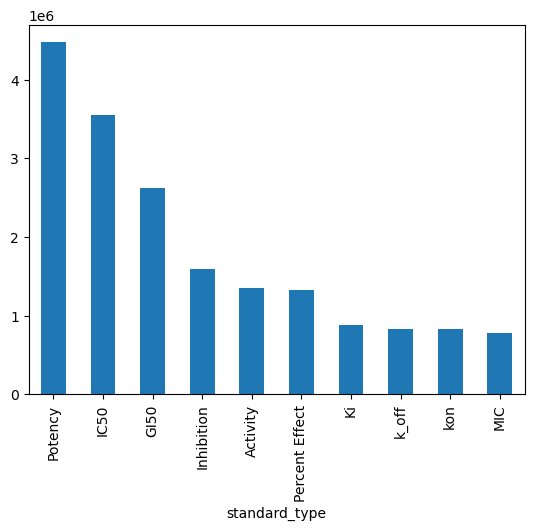

In [39]:
query= """
SELECT
standard_type,
COUNT(*) as n
FROM activities
GROUP BY standard_type
ORDER BY n DESC
LIMIT 10;"""

df = pd.read_sql(query, conn)
#df.head()
df.plot.bar(x="standard_type", y="n", legend=False)

In [42]:
### Which is the most studied target? 

query = """SELECT
    td.pref_name,
    COUNT(*) as n
FROM activities act
JOIN assays ass
ON act.assay_id = ass.assay_id
JOIN target_dictionary td
ON ass.tid = td.tid
GROUP BY td.pref_name
ORDER BY n DESC
LIMIT 10;""" 
df = pd.read_sql(query, conn)


In [43]:
df.head()

,pref_name,n
0,Unchecked,2291439
1,Plasmodium falciparum,971671
2,Rattus norvegicus,778099
3,ADMET,496635
4,Tyrosyl-DNA phosphodiesterase 1,345574


In [36]:
query = """
SELECT
    md.chembl_id,
    cs.canonical_smiles,
    td.pref_name AS target,
    act.standard_type,
    act.standard_value,
    act.standard_units
FROM activities act
JOIN molecule_dictionary md
    ON act.molregno = md.molregno
JOIN compound_structures cs
    ON md.molregno = cs.molregno
JOIN assays ass
    ON act.assay_id = ass.assay_id
JOIN target_dictionary td
    ON ass.tid = td.tid
WHERE act.standard_type = 'IC50'
AND act.standard_value IS NOT NULL
LIMIT 1000
"""

df = pd.read_sql(query, conn)
df.head()

,chembl_id,canonical_smiles,target,standard_type,standard_value,standard_units
0,CHEMBL113081,c1ccc(-c2nc3c(-c4nc5ccccc5o4)cccc3o2)cc1,DNA topoisomerase 2-alpha,IC50,100000.0,nM
1,CHEMBL324340,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...,Heparanase,IC50,2500.0,nM
2,CHEMBL324340,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...,NON-PROTEIN TARGET,IC50,50000.0,nM
3,CHEMBL109600,COc1ccccc1-c1ccc2oc(-c3ccc(OC)c(N4C(=O)c5ccc(C...,Heparanase,IC50,9000.0,nM
4,CHEMBL357278,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...,Peroxisomal acyl-coenzyme A oxidase 1,IC50,4000.0,nM
